# Representational Similarity Analysis (RSA)

Notes before I start:
* I was greatly helped by this reference: https://academic.oup.com/scan/article/14/11/1243/5693905
* The idea to use RSA was first suggested by Gemini, but the format it proposed for the test was not good

Okay, now to our main point: to determine if any lingering traces of attrited languages exist in attrited models, we'll examine neural traces of attrited models presented with L1 stimuli using a technique known as Representational Similarity Analysis (RSA).

This technique was developed to compare the same stimuli across different models, and in fact even across _types_ of models. RSA is essentially a second-order view, it doesn't compare model representations across models (incomparable), but it instead compares _patterns_ of model representations -- if two different models both believe two given samples are similar (however the samples are represented), then the models are more similar. The RSA technique is conducted by building a Representational Dissimilarity Matrix (RDM) per model, basically a view of how similarly or differently the model views each sample vs every other sample. Then, one can use the RDMs to conduct a permutation test for similarity, e.g.

1. Construct a "neural" RDM (nRDM) - A matrix, one entry per sample pair, of the cosine similarity between NN activation vectors
2. Construct a "conceptual" RDM (cRDM) - A binary matrix of whether samples share the feature of interest (e.g. "1" for two french samples vs. "0" for different languages)
3. Compute the observed similarity as the distance between the two RDMs -- similar RDMs mean the model represents (in some way) the feature of interest
4. Compute a null distribution by swapping the labels of one RDM and comparing it repeatedly with the "true" RDM
5. Compare the observed similarity with the null distribution to compute a p-value
6. Profit

We can use this technique to test various hypotheses. For example, "can a given model recognize similar sentences in a given language?" This might be done as follows:

1. Construct a nRDM for the target model  
    a. for each sample, compute a model representation, e.g. average activation of a given layer  
    b. construct a matrix using cosine distance between each pair of model representations
2. Construct a cRDM on the samples  
    a. for each sample, compute a conceptual representation, e.g. use a bag-of-words representation of the transcript  
    b. again, construct a matrix using cosine distance between each pair of representations
3. Compare the nRDM from the cRDM using a similarity metric -- recommended is a rank-correlation distance (e.g. Spearman correlation, Kendall’s Tau)
4. Compute a null distribution using rank-correlation distance between nRDM and cRDMs with labels swapped
5. Compute a p-value using the observed nRDM-cRDM distance vs. the null distribution
6. Profit

Hopefully, the results would be the following:

* Testing a English-only model on French samples would have low similarity between nRDM and cRDM (not above chance)
* Testing a French-only model on French samples would have high similarity between nRDM and cRDM (well above chance)
* Testing an attrited French model (FR->EN) on French samples would have similarity at least higher than chance (somewhere between en-only and fr-only)
* Testing an attrited French model (FR->EN) on German samples would have low similarity (not above chance)

We could go further and test things like:

* Test different layers of the model, perhaps the CNN outputs are better at keeping their representations, similar to how people are better at recognizing attrited phonemes
* Test different checkpoints of the model, if the nRDM still shows meaningful representations *after* accuracy goes to 0, maybe this is evidence of "masking"
* Compare different models: does Fr->En model generate more similar representations to Fr-only than En-only?

In [1]:
import torch, json, hyperpyyaml, textgrid
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# First things first, figure out how to build an RDM
# Load hyperparameters with models, data, etc.
overrides = {
    "output_folder": "bilingual_networks/results/nophonefb_fr250",
    "data_folder": "/home/competerscience/Documents/data/bilingual_networks/",
}
with open("experiments/pretrain_fr.yaml") as f:
    hparams = hyperpyyaml.load_hyperpyyaml(f, overrides=overrides)

# Load latest version of the model
hparams["checkpointer"].recover_if_possible()

# Load subset of data, let's try 1k I guess
with open(hparams["test_fr_manifest"]) as f:
    fr_manifest = json.load(f)
fr_subset = dict(list(fr_manifest.items())[:1000])

In [3]:
print("Size of subset:", len(fr_subset))
print("First example:", fr_subset[next(iter(fr_subset))])

Size of subset: 1000
First example: {'path': 'fr/common_voice_fr_19812198', 'lang': 'fr', 'duration': 6.79}


In [4]:
from speechbrain.dataio import audio_io
from pathlib import Path
import torchaudio

# Move features/model to device
device = "cuda"
feats = hparams["compute_features"].to(device)
model = hparams["model"].to(device)

# Iterate data and generate representations, one vector per sample
model_reps = []
for utt_id, sample in fr_subset.items():
    audio_path = hparams["data_folder"] / Path(sample["path"]).with_suffix(".mp3")
    audio, sr = audio_io.load(audio_path, always_2d=True)

    # Manually execute model parts to get phoneme rep
    with torch.no_grad():
        audio = torchaudio.functional.resample(audio.to(device), orig_freq=sr, new_freq=16000)
        features = feats(audio).transpose(1, 2)
        cnn_out = model.cnn(features).transpose(1, 2)
        rnn_out, _ = model.phone_rnn(cnn_out)

    # Average over time
    # TODO: Figure out if there's something better we can do here...
    model_reps.append(rnn_out.sum(dim=1).squeeze())
model_reps = torch.stack(model_reps, dim=0)
print(model_reps.shape)

torch.Size([1000, 256])


In [5]:
@torch.no_grad()
def make_rsm(representations):
    """Generates a Representational Similarity Matrix (RSM) which has equivalent statistical properties to an RDM"""
    # 1. Normalize the vectors to unit length (L2 norm)
    # Shape: (N, D)
    representations_norm = torch.nn.functional.normalize(representations, p=2, dim=1)
    #representations_norm = representations
    
    # 2. Perform Matrix Multiplication
    # (N, D) @ (D, N) -> (N, N)
    rsm = representations_norm @ representations_norm.T
    
    return rsm

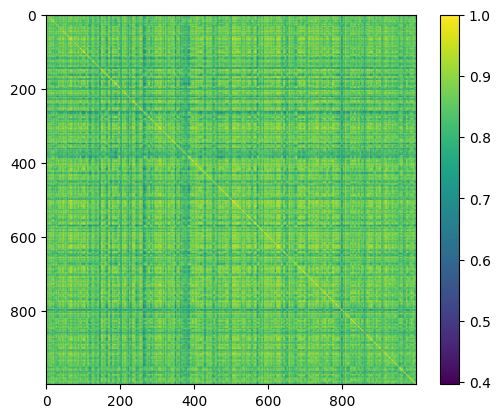

In [6]:
# yay, the first RDM!
neural_rsm = make_rsm(model_reps)
plt.imshow(neural_rsm.cpu())
plt.colorbar()
plt.show()

In [7]:
# Construct a conceptual RSM using words...
import data_sb, textgrid

data_sb.make_encoders(hparams)

concept_reps = []
for utt_id, sample in fr_subset.items():
    grid_path = hparams["data_folder"] / Path(sample["path"]).with_suffix(".TextGrid")
    grid = textgrid.TextGrid.fromFile(grid_path)
    words = [w.mark + "_fr" for w in grid.getList("words")[0] if w.mark]
    seq = hparams["word_encoder"].encode_sequence_torch(words)
    uniq = torch.unique(seq)
    coo = torch.sparse_coo_tensor(indices=uniq.unsqueeze(0), values=torch.ones(len(uniq)), size=(4000,))
    concept_reps.append(coo)

concept_reps = torch.stack(concept_reps, dim=0)
concept_reps.shape

torch.Size([1000, 4000])

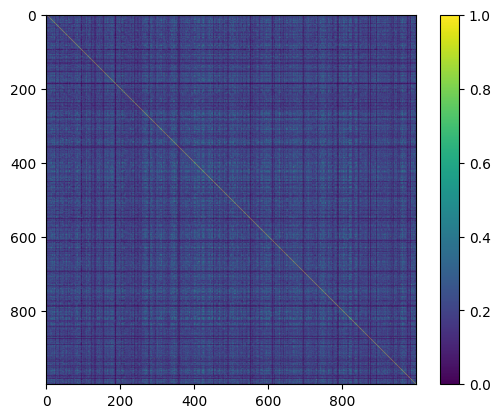

In [8]:
concept_rsm = make_rsm(concept_reps.to_dense().cuda())
plt.imshow(concept_rsm.cpu())
plt.colorbar()
plt.show()

In [9]:
# Okay, how do we correlate these beasts?
from torchmetrics.regression import SpearmanCorrCoef

def extract_tril(matrix):
    """Extract the bottom triangle (excluding the diagonal) into a vector"""
    indices = torch.tril_indices(matrix.size(0), matrix.size(1), offset=-1)
    tril_vector = matrix[indices[0], indices[1]]
    return tril_vector

def compute_spearman_rank(rsm1, rsm2):
    """Compute spearman rank based on EVERY PAIR of samples"""
    tril1 = extract_tril(rsm1)
    tril2 = extract_tril(rsm2)

    spearman_fn = SpearmanCorrCoef()
    spearman_val = spearman_fn(tril1, tril2)
    return spearman_val

In [10]:
compute_spearman_rank(neural_rsm, concept_rsm)

/home/competerscience/Documents/uvpy311/lib/python3.11/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `SpearmanCorrcoef` will save all targets and predictions in the buffer. For large datasets, this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)  # noqa: B028


tensor(0.0330, device='cuda:0')

In [11]:
def compute_null(neural_rsm, concept_reps, samples=100):
    null = []
    for i in range(samples):
        permutation = concept_reps[torch.randperm(len(concept_reps), device="cuda")]
        perm_rsm = make_rsm(permutation)
        null.append(compute_spearman_rank(neural_rsm, perm_rsm).cpu().detach())
    return np.array(null)

In [12]:
null = compute_null(neural_rsm, concept_reps.to_dense().cuda())

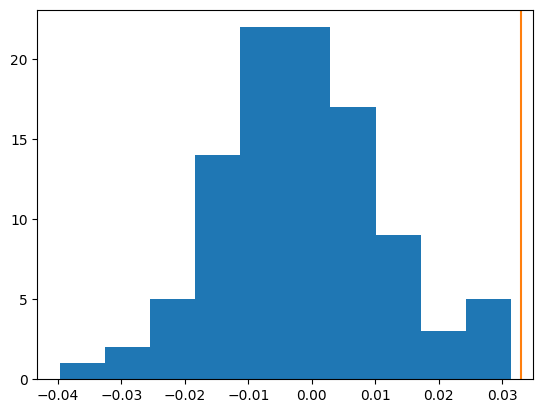

In [13]:
plt.hist(null, bins=10)
plt.axvline(0.0330, color="tab:orange")
plt.show()

In [14]:
sum(null > 0.033) / len(null)

np.float64(0.0)

In [15]:
# p-value of less than 0.05, I was hoping for a bit more significance but I guess that's something at least
# Maybe a better approach is to compare models. I can generate RDMs for en-only, fr-only and the bilingual model over time
# And for model representation, maybe I'll just use the average of the segment of the longest word
def get_longest_word_timing(grid_path):
    grid = textgrid.TextGrid.fromFile(grid_path)
    start, stop = 0, 0
    for w in grid.getList("words")[0]:
        if w.maxTime - w.minTime > stop - start:
            start, stop = w.minTime, w.maxTime
    return int(start * 100), int(stop * 100)


def load_hparams_and_checkpoint(model_path, overrides={}):
    # Load hyperparameters with models, data, etc.
    overrides["output_folder"] = "bilingual_networks/results/" + model_path
    overrides["data_folder"] = "/home/competerscience/Documents/data/bilingual_networks/"
    with open("experiments/pretrain_fr.yaml") as f:
        hparams = hyperpyyaml.load_hyperpyyaml(f, overrides=overrides)
    
    # Load latest version of the model
    ckpt = hparams["checkpointer"].recover_if_possible()
    if ckpt is None:
        raise ValueError(f"{model_path} is not valid")

    return hparams


def generate_reps_from_model(hparams, test_data):

    # Move features/model to device
    device = "cuda"
    feats = hparams["compute_features"].to(device)
    model = hparams["model"].to(device)
    
    # Iterate data and generate representations, one vector per sample
    model_reps = []
    for utt_id, sample in test_data.items():
        audio_path = hparams["data_folder"] / Path(sample["path"]).with_suffix(".mp3")
        audio, sr = audio_io.load(audio_path, always_2d=True)
    
        # Manually execute model parts to get representation
        with torch.no_grad():
            audio = torchaudio.functional.resample(audio.to(device), orig_freq=sr, new_freq=16000)
            features = feats(audio).transpose(1, 2)
            cnn_out = model.cnn(features).transpose(1, 2)
            rnn_out = model.phone_rnn(cnn_out)[0].squeeze()
            #rnn_out = model.word_rnn(rnn_out)[0].squeeze()
            #rnn_out = cnn_out.squeeze()
    
        # Load grid so we can find the longest word
        min_idx, max_idx = get_longest_word_timing(audio_path.with_suffix(".TextGrid"))

        # Representation is simply the mean over the longest word
        model_reps.append(rnn_out[min_idx:max_idx].mean(dim=0))

    # Combine into single tensor
    model_reps = torch.stack(model_reps, dim=0)
    return model_reps

In [16]:
hparams = load_hparams_and_checkpoint("nophonefb_fr250")
fr_reps = generate_reps_from_model(hparams, fr_subset)

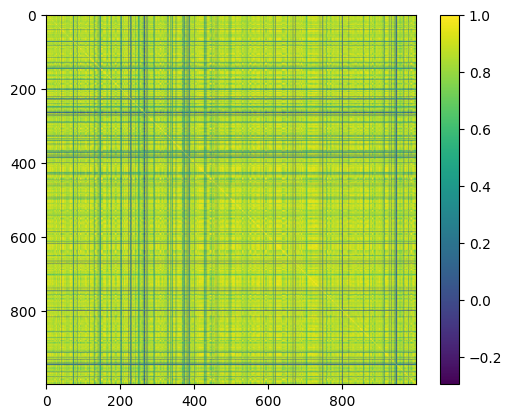

In [17]:
fr_rsm = make_rsm(fr_reps)
plt.imshow(fr_rsm.cpu())
plt.colorbar()
plt.show()

In [18]:
hparams = load_hparams_and_checkpoint("nophonefb_en250")
en_reps = generate_reps_from_model(hparams, fr_subset)

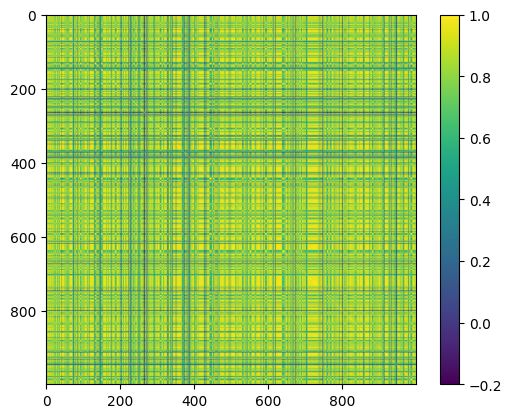

In [19]:
en_rsm = make_rsm(en_reps)
plt.imshow(en_rsm.cpu())
plt.colorbar()
plt.show()

In [20]:
compute_spearman_rank(en_rsm, fr_rsm)

tensor(0.9017, device='cuda:0')

In [21]:
hparams = load_hparams_and_checkpoint("nophonefb_fr250_en250")
fren_reps = generate_reps_from_model(hparams, fr_subset)

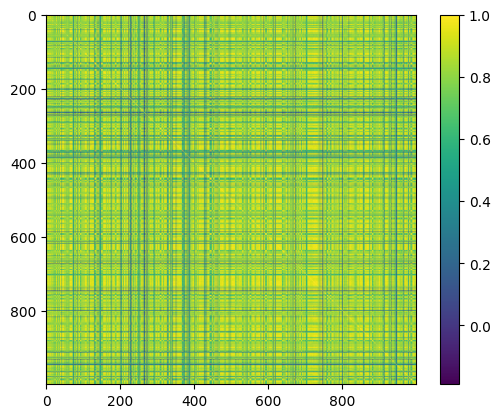

In [22]:
fren_rsm = make_rsm(fren_reps)
plt.imshow(fren_rsm.cpu())
plt.colorbar()
plt.show()

In [23]:
compute_spearman_rank(fren_rsm, fr_rsm)

tensor(0.9114, device='cuda:0')

In [24]:
compute_spearman_rank(fren_rsm, en_rsm)

tensor(0.9550, device='cuda:0')

In [25]:
from speechbrain.utils.checkpoints import ckpt_recency

ckpts = sorted(hparams["checkpointer"].list_checkpoints(), key=ckpt_recency)
phone_rnn_fr_scores = []
phone_rnn_en_scores = []
for ckpt in ckpts:
    hparams["checkpointer"].load_checkpoint(ckpt)
    fren_reps = generate_reps_from_model(hparams, fr_subset)
    fren_rsm = make_rsm(fren_reps)
    phone_rnn_fr_scores.append(compute_spearman_rank(fren_rsm, fr_rsm).cpu().detach())
    phone_rnn_en_scores.append(compute_spearman_rank(fren_rsm, en_rsm).cpu().detach())

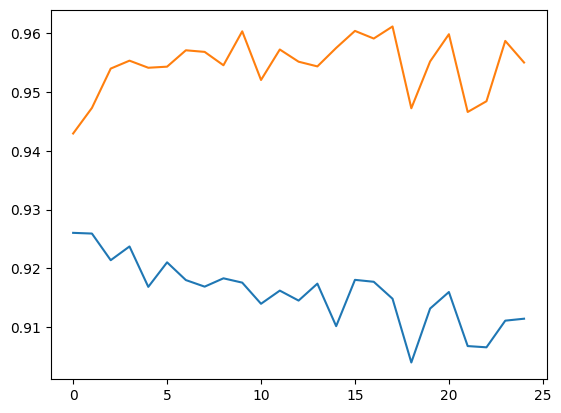

In [26]:
plt.plot(phone_rnn_fr_scores)
plt.plot(phone_rnn_en_scores)

In [27]:
hparams = load_hparams_and_checkpoint("nophonefb_fr250")
fr_reps = generate_reps_from_model(hparams, fr_subset)

In [28]:
fr_rsm = make_rsm(fr_reps)

In [29]:
hparams = load_hparams_and_checkpoint("nophonefb_en250")
en_reps = generate_reps_from_model(hparams, fr_subset)

In [30]:
en_rsm = make_rsm(en_reps)

In [31]:
from speechbrain.utils.checkpoints import ckpt_recency

hparams = load_hparams_and_checkpoint("nophonefb_fr250_en250")
ckpts = sorted(hparams["checkpointer"].list_checkpoints(), key=ckpt_recency)
cnn_fr_scores = []
cnn_en_scores = []
for ckpt in ckpts:
    hparams["checkpointer"].load_checkpoint(ckpt)
    fren_reps = generate_reps_from_model(hparams, fr_subset)
    fren_rsm = make_rsm(fren_reps)
    cnn_fr_scores.append(compute_spearman_rank(fren_rsm, fr_rsm).cpu().detach())
    cnn_en_scores.append(compute_spearman_rank(fren_rsm, en_rsm).cpu().detach())

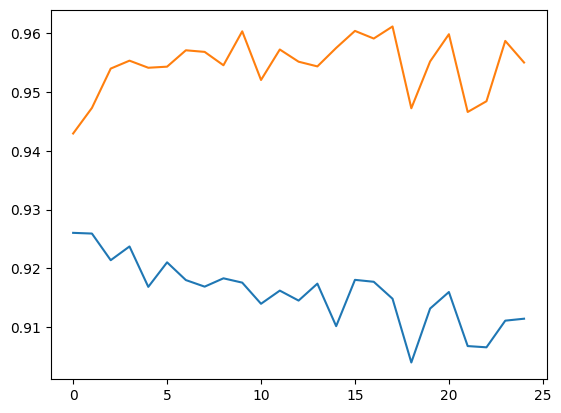

In [32]:
plt.plot(cnn_fr_scores)
plt.plot(cnn_en_scores)

In [33]:
hparams = load_hparams_and_checkpoint("nophonefb_fr250")
fr_reps = generate_reps_from_model(hparams, fr_subset)
fr_rsm = make_rsm(fr_reps)
hparams = load_hparams_and_checkpoint("nophonefb_en250")
en_reps = generate_reps_from_model(hparams, fr_subset)
en_rsm = make_rsm(en_reps)

In [34]:
hparams = load_hparams_and_checkpoint("nophonefb_fr250_en250")
ckpts = sorted(hparams["checkpointer"].list_checkpoints(), key=ckpt_recency)
word_rnn_fr_scores = []
word_rnn_en_scores = []
for ckpt in ckpts:
    hparams["checkpointer"].load_checkpoint(ckpt)
    fren_reps = generate_reps_from_model(hparams, fr_subset)
    fren_rsm = make_rsm(fren_reps)
    word_rnn_fr_scores.append(compute_spearman_rank(fren_rsm, fr_rsm).cpu().detach())
    word_rnn_en_scores.append(compute_spearman_rank(fren_rsm, en_rsm).cpu().detach())

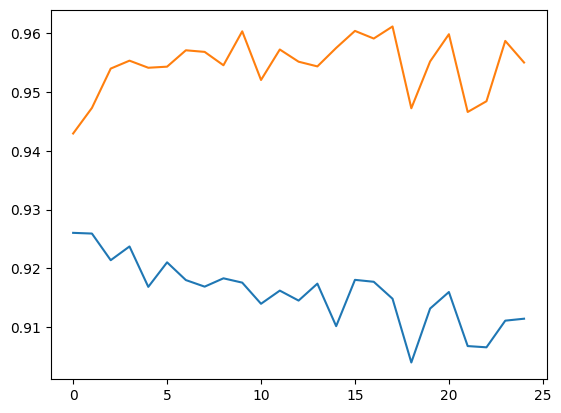

In [35]:
plt.plot(word_rnn_fr_scores)
plt.plot(word_rnn_en_scores)

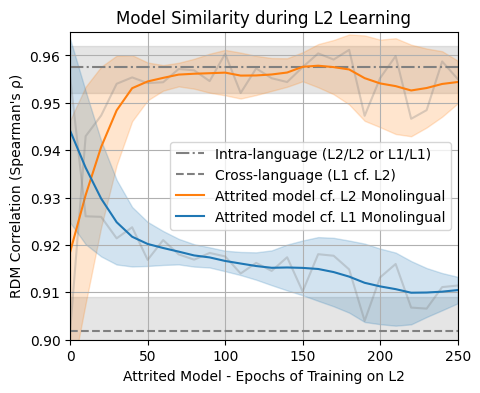

<Figure size 640x480 with 0 Axes>

In [71]:
import torch.nn.functional as F

def smoothify(x, window_size=7):
    n = window_size // 2
    
    # Triangular window that sums to 1 (by default sums to N)
    w = torch.bartlett_window(window_size + 1)[1:] / (n + 1)
    x = F.pad(x.view(1, 1, -1), (n, n), mode="replicate")
    return F.conv1d(x, weight=w.view(1, 1, -1)).view(-1)

def plot_smooth_std(ax, y_raw, label, window_size=7, color="C0"):
    x = (np.arange(len(y_raw))) * 10
    n = window_size // 2
    y_raw = torch.tensor(y_raw)
    y_smooth = smoothify(y_raw, window_size)
    
    # Calculate average distance to the smooth line
    y_std = smoothify(abs(y_raw - y_smooth), window_size)
    
    # 3. Define the upper and lower bounds for the shaded region
    y_upper = y_smooth + y_std * 2
    y_lower = y_smooth - y_std * 2
    
    # Plot the raw data (optional, for context)
    ax.plot(x, y_raw.view(-1), color='gray', alpha=0.3)#, label='Raw Data')
    
    # Plot the smoothed curve
    ax.plot(x, y_smooth, color=color, label=label)
    
    # Fill the area between the upper and lower bounds with a light color and transparency
    ax.fill_between(x, y_lower, y_upper, color=color, alpha=0.2)#, label='± 1 std dev')


# 4. Plot the results
fig, ax = plt.subplots(figsize=(5,4))

#plot_smooth_std(ax, word_rnn_fr_scores, "Word RNN FR")
#plot_smooth_std(ax, word_rnn_en_scores, "Word RNN EN", color="C1")

ax.axhline(0.9575, label="Intra-language (L2/L2 or L1/L1)", color="grey", linestyle="-.")
ax.axhline(0.9019, label="Cross-language (L1 cf. L2)", color="grey", linestyle="--")
ax.fill_between([0, 250], [0.894, 0.894], [0.909, 0.909], color="grey", alpha=0.2)
ax.fill_between([0, 250], [0.952, 0.952], [0.962, 0.962], color="grey", alpha=0.2)
plot_smooth_std(ax, [0.9019] + phone_rnn_en_scores, "Attrited model cf. L2 Monolingual", color="C1")
plot_smooth_std(ax, [0.9554] + phone_rnn_fr_scores, "Attrited model cf. L1 Monolingual", color="C0")
#plot_smooth_std(ax, cnn_fr_scores, "CNN FR", color="C2")
#plot_smooth_std(ax, cnn_en_scores, "CNN EN", color="C3")

#ax.axhline(0.9389, label="CNN En-Fr Final", color="C5", linestyle="--")

# Add plot details
ax.set_title("Model Similarity during L2 Learning")
ax.set_xlabel("Attrited Model - Epochs of Training on L2")
ax.set_ylabel("RDM Correlation (Spearman's ρ)")
ax.set_ylim((0.9, 0.965))
ax.margins(x=0)
#ax.set_yscale('log') # Set the y-axis to a logarithmic scale

ax.legend()
ax.grid(True)

plt.show()

plt.savefig("neural_trace.png", dpi=300, bbox_inches="tight")

In [37]:
# Check fr-fr and en-en similarity
hparams = load_hparams_and_checkpoint("nophonefb_fr250_take2")
fr_reps_take2 = generate_reps_from_model(hparams, fr_subset)
fr_rsm_take2 = make_rsm(fr_reps_take2)
hparams = load_hparams_and_checkpoint("nophonefb_en250_take2")
en_reps_take2 = generate_reps_from_model(hparams, fr_subset)
en_rsm_take2 = make_rsm(en_reps_take2)

In [38]:
compute_spearman_rank(fr_rsm, fr_rsm_take2)

tensor(0.9554, device='cuda:0')

In [39]:
compute_spearman_rank(en_rsm, en_rsm_take2)

tensor(0.9576, device='cuda:0')

In [40]:
compute_spearman_rank(fr_rsm_take2, en_rsm_take2)

tensor(0.9130, device='cuda:0')

In [41]:
compute_spearman_rank(fr_rsm, en_rsm_take2)

tensor(0.9092, device='cuda:0')

In [42]:
compute_spearman_rank(fr_rsm_take2, en_rsm)

tensor(0.9025, device='cuda:0')

In [43]:
hparams = load_hparams_and_checkpoint("nophonefb_en250_take2")
ckpts = list(sorted(hparams["checkpointer"].list_checkpoints(), key=ckpt_recency))
hparams["checkpointer"].load_checkpoint(ckpts[-2])

en_reps_take3 = generate_reps_from_model(hparams, fr_subset)
en_rsm_take3 = make_rsm(en_reps_take3)

In [44]:
compute_spearman_rank(fr_rsm_take2, en_rsm_take3)

tensor(0.9045, device='cuda:0')

In [45]:
compute_spearman_rank(fr_rsm, en_rsm_take3)

tensor(0.9036, device='cuda:0')

In [46]:
hparams = load_hparams_and_checkpoint("nophonefb_en250")
ckpts = list(sorted(hparams["checkpointer"].list_checkpoints(), key=ckpt_recency))
hparams["checkpointer"].load_checkpoint(ckpts[-2])

en_reps_take4 = generate_reps_from_model(hparams, fr_subset)
en_rsm_take4 = make_rsm(en_reps_take4)

In [47]:
compute_spearman_rank(fr_rsm_take2, en_rsm_take4)

tensor(0.8985, device='cuda:0')

In [48]:
compute_spearman_rank(fr_rsm, en_rsm_take4)

tensor(0.8985, device='cuda:0')

In [49]:
cross_langs = np.array([0.9130, 0.9092, 0.9025, 0.9017, 0.9045, 0.9036, 0.8985, 0.8985, 0.8972, 0.9067, 0.9023, 0.8964])
print("Mean cross-lang correlation:", np.mean(cross_langs))
print("Standard deviation in corr:", np.std(cross_langs))

Mean cross-lang correlation: 0.9028416666666668
Standard deviation in corr: 0.004783384146071587


In [50]:
np.mean(cross_langs) - np.std(cross_langs) * 2

np.float64(0.8932748983745236)

In [51]:
np.mean(cross_langs) + np.std(cross_langs) * 2

np.float64(0.91240843495881)

In [52]:
hparams = load_hparams_and_checkpoint("nophonefb_fr250_take2")
ckpts = list(sorted(hparams["checkpointer"].list_checkpoints(), key=ckpt_recency))
hparams["checkpointer"].load_checkpoint(ckpts[-2])

fr_reps_take3 = generate_reps_from_model(hparams, fr_subset)
fr_rsm_take3 = make_rsm(fr_reps_take3)

In [53]:
compute_spearman_rank(fr_rsm_take3, en_rsm)

tensor(0.8972, device='cuda:0')

In [54]:
compute_spearman_rank(fr_rsm_take3, en_rsm_take2)

tensor(0.9067, device='cuda:0')

In [55]:
compute_spearman_rank(fr_rsm_take3, en_rsm_take3)

tensor(0.9023, device='cuda:0')

In [56]:
compute_spearman_rank(fr_rsm_take3, en_rsm_take4)

tensor(0.8964, device='cuda:0')

In [57]:
# AND NOW FOR intra-language
compute_spearman_rank(fr_rsm, fr_rsm_take3)

tensor(0.9548, device='cuda:0')

In [58]:
compute_spearman_rank(en_rsm, en_rsm_take3)

tensor(0.9597, device='cuda:0')

In [59]:
compute_spearman_rank(en_rsm_take2, en_rsm_take4)

tensor(0.9469, device='cuda:0')

In [60]:
hparams = load_hparams_and_checkpoint("nophonefb_fr250")
ckpts = list(sorted(hparams["checkpointer"].list_checkpoints(), key=ckpt_recency))
hparams["checkpointer"].load_checkpoint(ckpts[-2])

fr_reps_take4 = generate_reps_from_model(hparams, fr_subset)
fr_rsm_take4 = make_rsm(fr_reps_take4)

In [61]:
compute_spearman_rank(fr_rsm_take2, fr_rsm_take4)

tensor(0.9534, device='cuda:0')

In [62]:
compute_spearman_rank(fr_rsm_take3, fr_rsm_take4)

tensor(0.9563, device='cuda:0')

In [63]:
compute_spearman_rank(en_rsm_take3, en_rsm_take4)

tensor(0.9615, device='cuda:0')

In [64]:
intra_lang = np.array([0.9554, 0.9576, 0.9548, 0.9597, 0.9534, 0.9563, 0.9615, 0.9469])
print("Mean cross-lang correlation:", np.mean(intra_lang))
print("Standard deviation in corr:", np.std(intra_lang))

Mean cross-lang correlation: 0.9557
Standard deviation in corr: 0.00414185948578656


In [65]:
print(np.mean(intra_lang) - np.std(intra_lang) * 2)
print(np.mean(intra_lang) + np.std(intra_lang) * 2)

0.9474162810284269
0.9639837189715731


In [66]:
from scipy import stats

stats.ttest_ind(cross_langs, phone_rnn_fr_scores[-6:])

TtestResult(statistic=np.float64(-3.461804057454003), pvalue=np.float64(0.003212500364120688), df=np.float64(16.0))

In [67]:
stats.ttest_ind(intra_lang, phone_rnn_en_scores[-6:])

TtestResult(statistic=np.float64(0.6540945039579131), pvalue=np.float64(0.5253882696967933), df=np.float64(12.0))

In [68]:
# OKAY HOW ABOUT 30 EPOCHS BEFORE ATTRITION?

hparams = load_hparams_and_checkpoint("nophonefb_fr30_en250")

ckpts = sorted(hparams["checkpointer"].list_checkpoints(), key=ckpt_recency)
thirtyL1_fr_scores = []
thirtyL1_en_scores = []
for ckpt in ckpts:
    hparams["checkpointer"].load_checkpoint(ckpt)
    fren_reps = generate_reps_from_model(hparams, fr_subset)
    fren_rsm = make_rsm(fren_reps)
    thirtyL1_fr_scores.append(compute_spearman_rank(fren_rsm, fr_rsm).cpu().detach())
    thirtyL1_en_scores.append(compute_spearman_rank(fren_rsm, en_rsm).cpu().detach())

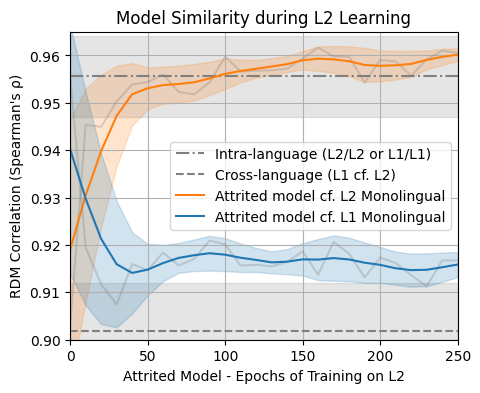

In [73]:

# 4. Plot the results
fig, ax = plt.subplots(figsize=(5,4))

#plot_smooth_std(ax, word_rnn_fr_scores, "Word RNN FR")
#plot_smooth_std(ax, word_rnn_en_scores, "Word RNN EN", color="C1")

ax.axhline(0.9557, label="Intra-language (L2/L2 or L1/L1)", color="grey", linestyle="-.")
ax.axhline(0.9019, label="Cross-language (L1 cf. L2)", color="grey", linestyle="--")
ax.fill_between([0, 250], [0.893, 0.893], [0.912, 0.912], color="grey", alpha=0.2)
ax.fill_between([0, 250], [0.947, 0.947], [0.964, 0.964], color="grey", alpha=0.2)
plot_smooth_std(ax, [0.9028] + thirtyL1_en_scores, "Attrited model cf. L2 Monolingual", color="C1")
plot_smooth_std(ax, [0.9554] + thirtyL1_fr_scores, "Attrited model cf. L1 Monolingual", color="C0")
#plot_smooth_std(ax, cnn_fr_scores, "CNN FR", color="C2")
#plot_smooth_std(ax, cnn_en_scores, "CNN EN", color="C3")

#ax.axhline(0.9389, label="CNN En-Fr Final", color="C5", linestyle="--")

# Add plot details
ax.set_title("Model Similarity during L2 Learning")
ax.set_xlabel("Attrited Model - Epochs of Training on L2")
ax.set_ylabel("RDM Correlation (Spearman's ρ)")
ax.set_ylim((0.9, 0.965))
ax.margins(x=0)
#ax.set_yscale('log') # Set the y-axis to a logarithmic scale

ax.legend()
ax.grid(True)

#plt.show()
plt.savefig("neural_trace.png", dpi=300, bbox_inches="tight")

In [74]:
stats.ttest_ind(cross_langs, thirtyL1_fr_scores[-6:])

TtestResult(statistic=np.float64(-5.739169243171405), pvalue=np.float64(3.0462757012772493e-05), df=np.float64(16.0))

In [75]:
stats.ttest_ind(intra_lang, thirtyL1_en_scores[-6:])

TtestResult(statistic=np.float64(-1.7169872840981988), pvalue=np.float64(0.11165571924604215), df=np.float64(12.0))

In [76]:
# WHAT ABOUT ENGLISH? DO THE MODEL REPRESENTATION COMPARISONS LOOK THE SAME?
# Load subset of data, let's try 1k I guess
with open("manifests/test_en.json") as f:
    en_manifest = json.load(f)
en_subset = dict(list(en_manifest.items())[:1000])

hparams = load_hparams_and_checkpoint("nophonefb_fr250")
fr_reps_en_data = generate_reps_from_model(hparams, en_subset)
fr_rsm_en_data = make_rsm(fr_reps_en_data)

In [77]:
hparams = load_hparams_and_checkpoint("nophonefb_en250")
en_reps_en_data = generate_reps_from_model(hparams, en_subset)
en_rsm_en_data = make_rsm(en_reps_en_data)

In [78]:
# Check fr-fr and en-en similarity
hparams = load_hparams_and_checkpoint("nophonefb_fr250_take2")
fr_reps_en_data_take2 = generate_reps_from_model(hparams, en_subset)
fr_rsm_en_data_take2 = make_rsm(fr_reps_en_data_take2)
hparams = load_hparams_and_checkpoint("nophonefb_en250_take2")
en_reps_en_data_take2 = generate_reps_from_model(hparams, en_subset)
en_rsm_en_data_take2 = make_rsm(en_reps_en_data_take2)

In [79]:
for rsm1 in [fr_rsm_en_data, fr_rsm_en_data_take2]:
    for rsm2 in [en_rsm_en_data, en_rsm_en_data_take2]:
        print(compute_spearman_rank(rsm1, rsm2))

tensor(0.9312, device='cuda:0')
tensor(0.9423, device='cuda:0')
tensor(0.9298, device='cuda:0')
tensor(0.9412, device='cuda:0')


In [80]:
compute_spearman_rank(fr_rsm_en_data, fr_rsm_en_data_take2)

tensor(0.9735, device='cuda:0')

In [81]:
compute_spearman_rank(en_rsm_en_data, en_rsm_en_data_take2)

tensor(0.9696, device='cuda:0')

In [82]:
# OKAY HOW ABOUT 30 EPOCHS BEFORE ATTRITION?

hparams = load_hparams_and_checkpoint("nophonefb_fr30_en250")

ckpts = sorted(hparams["checkpointer"].list_checkpoints(), key=ckpt_recency)
thirtyL1_fr_scores_en_data = []
thirtyL1_en_scores_en_data = []
for ckpt in ckpts:
    hparams["checkpointer"].load_checkpoint(ckpt)
    fren_reps = generate_reps_from_model(hparams, en_subset)
    fren_rsm = make_rsm(fren_reps)
    thirtyL1_fr_scores_en_data.append(compute_spearman_rank(fren_rsm, fr_rsm_en_data).cpu().detach())
    thirtyL1_en_scores_en_data.append(compute_spearman_rank(fren_rsm, en_rsm_en_data).cpu().detach())

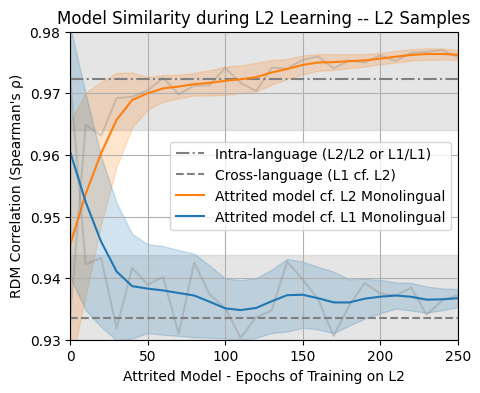

In [83]:

# 4. Plot the results
fig, ax = plt.subplots(figsize=(5,4))

#plot_smooth_std(ax, word_rnn_fr_scores, "Word RNN FR")
#plot_smooth_std(ax, word_rnn_en_scores, "Word RNN EN", color="C1")

ax.axhline(0.9723, label="Intra-language (L2/L2 or L1/L1)", color="grey", linestyle="-.")
ax.axhline(0.9336, label="Cross-language (L1 cf. L2)", color="grey", linestyle="--")
ax.fill_between([0, 250], [0.9234, 0.9234], [0.9438, 0.9438], color="grey", alpha=0.2)
ax.fill_between([0, 250], [0.964, 0.964], [0.981, 0.981], color="grey", alpha=0.2)
plot_smooth_std(ax, [0.9336] + thirtyL1_en_scores_en_data, "Attrited model cf. L2 Monolingual", color="C1")
plot_smooth_std(ax, [0.9723] + thirtyL1_fr_scores_en_data, "Attrited model cf. L1 Monolingual", color="C0")
#plot_smooth_std(ax, cnn_fr_scores, "CNN FR", color="C2")
#plot_smooth_std(ax, cnn_en_scores, "CNN EN", color="C3")

#ax.axhline(0.9389, label="CNN En-Fr Final", color="C5", linestyle="--")

# Add plot details
ax.set_title("Model Similarity during L2 Learning -- L2 Samples")
ax.set_xlabel("Attrited Model - Epochs of Training on L2")
ax.set_ylabel("RDM Correlation (Spearman's ρ)")
ax.set_ylim((0.93, 0.98))
ax.margins(x=0)
#ax.set_yscale('log') # Set the y-axis to a logarithmic scale

ax.legend()
ax.grid(True)

plt.show()

In [84]:
hparams = load_hparams_and_checkpoint("nophonefb_en250_take2")
ckpts = list(sorted(hparams["checkpointer"].list_checkpoints(), key=ckpt_recency))
hparams["checkpointer"].load_checkpoint(ckpts[-2])

en_reps_en_data_take3 = generate_reps_from_model(hparams, en_subset)
en_rsm_en_data_take3 = make_rsm(en_reps_en_data_take3)

hparams = load_hparams_and_checkpoint("nophonefb_en250")
ckpts = list(sorted(hparams["checkpointer"].list_checkpoints(), key=ckpt_recency))
hparams["checkpointer"].load_checkpoint(ckpts[-2])

en_reps_en_data_take4 = generate_reps_from_model(hparams, en_subset)
en_rsm_en_data_take4 = make_rsm(en_reps_en_data_take4)

hparams = load_hparams_and_checkpoint("nophonefb_fr250_take2")
ckpts = list(sorted(hparams["checkpointer"].list_checkpoints(), key=ckpt_recency))
hparams["checkpointer"].load_checkpoint(ckpts[-2])

fr_reps_en_data_take3 = generate_reps_from_model(hparams, en_subset)
fr_rsm_en_data_take3 = make_rsm(fr_reps_en_data_take3)

hparams = load_hparams_and_checkpoint("nophonefb_fr250")
ckpts = list(sorted(hparams["checkpointer"].list_checkpoints(), key=ckpt_recency))
hparams["checkpointer"].load_checkpoint(ckpts[-2])

fr_reps_en_data_take4 = generate_reps_from_model(hparams, en_subset)
fr_rsm_en_data_take4 = make_rsm(fr_reps_en_data_take4)

In [85]:
same_langs = []
for rsm1 in [fr_rsm_en_data, fr_rsm_en_data_take4]:
    for rsm2 in [fr_rsm_en_data_take2, fr_rsm_en_data_take3]:
        same_langs.append(compute_spearman_rank(rsm1, rsm2).cpu().detach())

In [86]:
for rsm1 in [en_rsm_en_data, en_rsm_en_data_take4]:
    for rsm2 in [en_rsm_en_data_take2, en_rsm_en_data_take3]:
        same_langs.append(compute_spearman_rank(rsm1, rsm2).cpu().detach())

In [87]:
print(torch.mean(torch.tensor(same_langs)))
print(torch.std(torch.tensor(same_langs)))

tensor(0.9723)
tensor(0.0043)


In [88]:
print(0.9723 + 2 * 0.0043)
print(0.9723 - 2 * 0.0043)

0.9809000000000001
0.9637


In [89]:
cross_langs = []
for rsm1 in [fr_rsm_en_data, fr_rsm_en_data_take2, fr_rsm_en_data_take3, fr_rsm_en_data_take4]:
    for rsm2 in [en_rsm_en_data, en_rsm_en_data_take2, en_rsm_en_data_take3, en_rsm_en_data_take4]:
        cross_langs.append(compute_spearman_rank(rsm1, rsm2).cpu().detach())

In [90]:
print(torch.mean(torch.tensor(cross_langs)))
print(torch.std(torch.tensor(cross_langs)))

tensor(0.9336)
tensor(0.0051)


In [91]:
print(0.9336 + 2 * 0.0051)
print(0.9336 - 2 * 0.0051)

0.9438
0.9234


In [92]:
stats.ttest_ind(cross_langs, thirtyL1_fr_scores_en_data[-6:])

TtestResult(statistic=np.float32(-1.4855177), pvalue=np.float32(0.1529998), df=np.float32(20.0))

In [93]:
stats.ttest_ind(same_langs, thirtyL1_en_scores_en_data[-6:])

TtestResult(statistic=np.float32(-2.2210355), pvalue=np.float32(0.046352126), df=np.float32(12.0))

## CHECK OTHER LANGUAGE PAIRS

1. De -> Fr
2. De -> En
3. Fr -> De
4. Fr -> En

In [94]:
hparams = load_hparams_and_checkpoint("nophonefb_de250", overrides={"word_outputs": 11998, "phone_outputs": 51})
de_reps_fr_data = generate_reps_from_model(hparams, fr_subset)
de_rsm_fr_data = make_rsm(de_reps_fr_data)

In [95]:
de_fr_score = compute_spearman_rank(fr_rsm, de_rsm_fr_data).cpu().detach()
print(f"Similarity of De and Fr models on French samples: {de_fr_score:.1%}")

Similarity of De and Fr models on French samples: 88.5%


In [96]:
# OKAY HOW ABOUT 30 EPOCHS BEFORE ATTRITION?

hparams = load_hparams_and_checkpoint("nophonefb_de30_fr250", overrides={"word_outputs": 11998, "phone_outputs": 51})

ckpts = sorted(hparams["checkpointer"].list_checkpoints(), key=ckpt_recency)
de30fr250_cf_fr_scores = []
de30fr250_cf_de_scores = []
for ckpt in ckpts:
    hparams["checkpointer"].load_checkpoint(ckpt)
    reps = generate_reps_from_model(hparams, fr_subset)
    rsm = make_rsm(reps)
    de30fr250_cf_fr_scores.append(compute_spearman_rank(rsm, fr_rsm).cpu().detach())
    de30fr250_cf_de_scores.append(compute_spearman_rank(rsm, de_rsm_fr_data).cpu().detach())

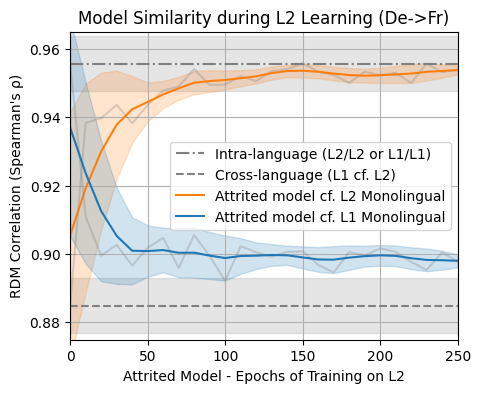

In [113]:

# 4. Plot the results
fig, ax = plt.subplots(figsize=(5,4))

#plot_smooth_std(ax, word_rnn_fr_scores, "Word RNN FR")
#plot_smooth_std(ax, word_rnn_en_scores, "Word RNN EN", color="C1")

def plot_baseline(score, ax, label, linestyle):
    ax.axhline(score, label=label, color="grey", linestyle=linestyle)
    low, high = score - 2 * 0.004, score + 2 * 0.004
    ax.fill_between([0, 250], [low, low], [high, high], color="grey", alpha=0.2)

fr_fr_score = 0.9557
plot_baseline(score=fr_fr_score, ax=ax, label="Intra-language (L2/L2 or L1/L1)", linestyle="-.")
plot_baseline(score=de_fr_score, ax=ax, label="Cross-language (L1 cf. L2)", linestyle="--")

plot_smooth_std(ax, [de_fr_score] + de30fr250_cf_fr_scores, "Attrited model cf. L2 Monolingual", color="C1")
plot_smooth_std(ax, [fr_fr_score] + de30fr250_cf_de_scores, "Attrited model cf. L1 Monolingual", color="C0")

# Add plot details
ax.set_title("Model Similarity during L2 Learning (De->Fr)")
ax.set_xlabel("Attrited Model - Epochs of Training on L2")
ax.set_ylabel("RDM Correlation (Spearman's ρ)")
ax.set_ylim((de_fr_score - 0.01, 0.965))
ax.margins(x=0)
#ax.set_yscale('log') # Set the y-axis to a logarithmic scale

ax.legend()
ax.grid(True)

#plt.show()
plt.savefig("de2fr_sim.png", dpi=300, bbox_inches="tight")

In [98]:
hparams = load_hparams_and_checkpoint("nophonefb_de250", overrides={"word_outputs": 11998, "phone_outputs": 51})
de_reps_en_data = generate_reps_from_model(hparams, en_subset)
de_rsm_en_data = make_rsm(de_reps_en_data)

In [99]:
de_en_score = compute_spearman_rank(en_rsm_en_data, de_rsm_en_data).cpu().detach()
print(f"Similarity of De and En models on English samples: {de_en_score:.1%}")

Similarity of De and En models on English samples: 94.0%


In [100]:
# OKAY HOW ABOUT 30 EPOCHS BEFORE ATTRITION?

hparams = load_hparams_and_checkpoint("nophonefb_de30_en250", overrides={"word_outputs": 11998, "phone_outputs": 51})

ckpts = sorted(hparams["checkpointer"].list_checkpoints(), key=ckpt_recency)
de30en250_cf_en_scores = []
de30en250_cf_de_scores = []
for ckpt in ckpts:
    hparams["checkpointer"].load_checkpoint(ckpt)
    reps = generate_reps_from_model(hparams, en_subset)
    rsm = make_rsm(reps)
    de30en250_cf_en_scores.append(compute_spearman_rank(rsm, en_rsm_en_data).cpu().detach())
    de30en250_cf_de_scores.append(compute_spearman_rank(rsm, de_rsm_en_data).cpu().detach())

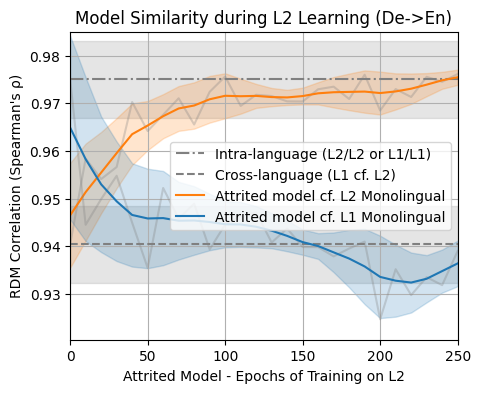

In [101]:

# 4. Plot the results
fig, ax = plt.subplots(figsize=(5,4))

def plot_baseline(score, ax, label, linestyle):
    ax.axhline(score, label=label, color="grey", linestyle=linestyle)
    low, high = score - 2 * 0.004, score + 2 * 0.004
    ax.fill_between([0, 250], [low, low], [high, high], color="grey", alpha=0.2)

en_en_score = 0.975
plot_baseline(score=en_en_score, ax=ax, label="Intra-language (L2/L2 or L1/L1)", linestyle="-.")
plot_baseline(score=de_en_score, ax=ax, label="Cross-language (L1 cf. L2)", linestyle="--")

plot_smooth_std(ax, [de_en_score] + de30en250_cf_en_scores, "Attrited model cf. L2 Monolingual", color="C1")
plot_smooth_std(ax, [en_en_score] + de30en250_cf_de_scores, "Attrited model cf. L1 Monolingual", color="C0")

# Add plot details
ax.set_title("Model Similarity during L2 Learning (De->En)")
ax.set_xlabel("Attrited Model - Epochs of Training on L2")
ax.set_ylabel("RDM Correlation (Spearman's ρ)")
ax.set_ylim((de_en_score - 0.02, 0.985))
ax.margins(x=0)
#ax.set_yscale('log') # Set the y-axis to a logarithmic scale

ax.legend()
ax.grid(True)

plt.show()

In [102]:
de_en_score = compute_spearman_rank(en_rsm_en_data_take2, de_rsm_en_data).cpu().detach()
print(f"Similarity of De and En models on English samples: {de_en_score:.1%}")

Similarity of De and En models on English samples: 93.7%


In [103]:
# OKAY, NOW TRY FR->DE, is there something about the test data that matters?
# Load subset of data, let's try 1k I guess
with open("manifests/test_de.json") as f:
    de_manifest = json.load(f)
de_subset = dict(list(de_manifest.items())[:1000])

hparams = load_hparams_and_checkpoint("nophonefb_de250", overrides={"word_outputs": 11998, "phone_outputs": 51})
de_reps_de_data = generate_reps_from_model(hparams, de_subset)
de_rsm_de_data = make_rsm(de_reps_de_data)

In [104]:
hparams = load_hparams_and_checkpoint("nophonefb_fr250")
fr_reps_de_data = generate_reps_from_model(hparams, de_subset)
fr_rsm_de_data = make_rsm(fr_reps_de_data)

In [105]:
fr_de_score = compute_spearman_rank(fr_rsm_de_data, de_rsm_de_data).cpu().detach()
print(f"Similarity of Fr and De models on German samples: {fr_de_score:.1%}")

Similarity of Fr and De models on German samples: 93.5%


In [106]:
hparams = load_hparams_and_checkpoint("nophonefb_de250_take2", overrides={"word_outputs": 11998, "phone_outputs": 51})
de_reps_de_data_take2 = generate_reps_from_model(hparams, de_subset)
de_rsm_de_data_take2 = make_rsm(de_reps_de_data_take2)

In [107]:
de_de_score = compute_spearman_rank(de_rsm_de_data_take2, de_rsm_de_data).cpu().detach()
print(f"Similarity of De models on German samples: {de_de_score:.1%}")

Similarity of De models on German samples: 97.3%


In [108]:
fr_de_score = compute_spearman_rank(fr_rsm_de_data, de_rsm_de_data_take2).cpu().detach()
print(f"Similarity of Fr and De models on German samples: {fr_de_score:.1%}")

Similarity of Fr and De models on German samples: 92.4%


In [109]:
# OKAY HOW ABOUT 30 EPOCHS BEFORE ATTRITION?

hparams = load_hparams_and_checkpoint("nophonefb_fr30_de250")

ckpts = sorted(hparams["checkpointer"].list_checkpoints(), key=ckpt_recency)
fr30de250_cf_de_scores = []
fr30de250_cf_fr_scores = []
for ckpt in ckpts:
    hparams["checkpointer"].load_checkpoint(ckpt)
    reps = generate_reps_from_model(hparams, de_subset)
    rsm = make_rsm(reps)
    fr30de250_cf_de_scores.append(compute_spearman_rank(rsm, de_rsm_de_data).cpu().detach())
    fr30de250_cf_fr_scores.append(compute_spearman_rank(rsm, fr_rsm_de_data).cpu().detach())

In [111]:
def plot_sim(intra_base, cross_base, intra_scores, cross_scores, label):
    # 4. Plot the results
    fig, ax = plt.subplots(figsize=(5,4))
    
    def plot_baseline(score, ax, label, linestyle):
        ax.axhline(score, label=label, color="grey", linestyle=linestyle)
        low, high = score - 2 * 0.004, score + 2 * 0.004
        ax.fill_between([0, 250], [low, low], [high, high], color="grey", alpha=0.2)
    
    plot_baseline(score=intra_base, ax=ax, label="Intra-language (L2/L2 or L1/L1)", linestyle="-.")
    plot_baseline(score=cross_base, ax=ax, label="Cross-language (L1 cf. L2)", linestyle="--")
    
    plot_smooth_std(ax, [cross_base] + intra_scores, "Attrited model cf. L2 Monolingual", color="C1")
    plot_smooth_std(ax, [intra_base] + cross_scores, "Attrited model cf. L1 Monolingual", color="C0")
    
    # Add plot details
    ax.set_title(f"Model Similarity during L2 Learning ({label})")
    ax.set_xlabel("Attrited Model - Epochs of Training on L2")
    ax.set_ylabel("RDM Correlation (Spearman's ρ)")
    ax.set_ylim((cross_base - 0.02, intra_base + 0.01))
    ax.margins(x=0)
    #ax.set_yscale('log') # Set the y-axis to a logarithmic scale
    
    ax.legend()
    ax.grid(True)
    
    #plt.show()

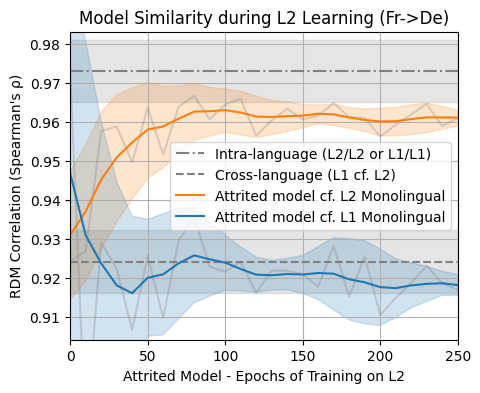

In [112]:
plot_sim(de_de_score, fr_de_score, fr30de250_cf_de_scores, fr30de250_cf_fr_scores, "Fr->De")
plt.savefig("fr2de_sim.png", dpi=300, bbox_inches="tight")

In [114]:
hparams = load_hparams_and_checkpoint("nophonefb_en250")
en_reps_de_data = generate_reps_from_model(hparams, de_subset)
en_rsm_de_data = make_rsm(en_reps_de_data)

In [115]:
# OKAY HOW ABOUT 30 EPOCHS BEFORE ATTRITION?

hparams = load_hparams_and_checkpoint("nophonefb_en30_de250")

ckpts = sorted(hparams["checkpointer"].list_checkpoints(), key=ckpt_recency)
en30de250_cf_de_scores = []
en30de250_cf_en_scores = []
for ckpt in ckpts:
    hparams["checkpointer"].load_checkpoint(ckpt)
    reps = generate_reps_from_model(hparams, de_subset)
    rsm = make_rsm(reps)
    en30de250_cf_de_scores.append(compute_spearman_rank(rsm, de_rsm_de_data).cpu().detach())
    en30de250_cf_en_scores.append(compute_spearman_rank(rsm, en_rsm_de_data).cpu().detach())

In [116]:
en_de_score = compute_spearman_rank(en_rsm_de_data, de_rsm_de_data_take2).cpu().detach()
print(f"Similarity of En and De models on German samples: {en_de_score:.1%}")

Similarity of En and De models on German samples: 95.2%


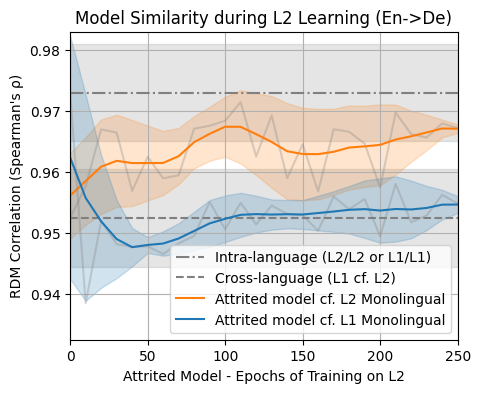

In [117]:
plot_sim(de_de_score, en_de_score, en30de250_cf_de_scores, en30de250_cf_en_scores, "En->De")

# Flat Learning Rate

To verify that this result is not a fluke result of learning rate dynamics, we try again with flat learning rate (0.001)

In [131]:
# Let's try an alternate method:
def generate_reps_from_model(hparams, test_data):

    # Move features/model to device
    device = "cuda"
    feats = hparams["compute_features"].to(device)
    model = hparams["model"].to(device)
    
    # Iterate data and generate representations, one vector per sample
    model_reps = []
    for utt_id, sample in test_data.items():
        audio_path = hparams["data_folder"] / Path(sample["path"]).with_suffix(".mp3")
        audio, sr = audio_io.load(audio_path, always_2d=True)
    
        # Manually execute model parts to get representation
        with torch.no_grad():
            audio = torchaudio.functional.resample(audio.to(device), orig_freq=sr, new_freq=16000)
            features = feats(audio).transpose(1, 2)
            cnn_out = model.cnn(features).transpose(1, 2)
            rnn_out = model.phone_rnn(cnn_out)[0].squeeze()
            #rnn_out = model.word_rnn(rnn_out)[0].squeeze()
            #rnn_out = cnn_out.squeeze()
    
        # Load grid so we can find the longest word
        #min_idx, max_idx = get_longest_word_timing(audio_path.with_suffix(".TextGrid"))

        # Representation is simply the mean over the longest word
        #model_reps.append(rnn_out[min_idx:max_idx].mean(dim=0))
        model_reps.append(rnn_out.mean(dim=0))

    # Combine into single tensor
    model_reps = torch.stack(model_reps, dim=0)
    return model_reps

In [179]:
def smoothify(x, window_size=7):
    n = window_size // 2
    
    # Triangular window that sums to 1 (by default sums to N)
    w = torch.bartlett_window(window_size + 1)[1:] / (n + 1)
    x = F.pad(x.view(1, 1, -1), (n, n), mode="replicate")
    return F.conv1d(x, weight=w.view(1, 1, -1)).view(-1)

def plot_smooth_std(ax, xs, y_raw, label, window_size=7, color="C0"):

    # Since the switch occurs at 5 epochs, all checkpoints are off by 5
    n = window_size // 2
    y_raw = torch.tensor(y_raw)
    y_smooth = smoothify(y_raw, window_size)
    
    # Calculate average distance to the smooth line
    y_std = smoothify(abs(y_raw - y_smooth), window_size)
    
    # 3. Define the upper and lower bounds for the shaded region
    y_upper = y_smooth + y_std * 2
    y_lower = y_smooth - y_std * 2
    
    # Plot the raw data (optional, for context)
    ax.plot(xs, y_raw.view(-1), color='gray', alpha=0.3)#, label='Raw Data')
    
    # Plot the smoothed curve
    ax.plot(xs, y_smooth, color=color, label=label)
    
    # Fill the area between the upper and lower bounds with a light color and transparency
    ax.fill_between(xs, y_lower, y_upper, color=color, alpha=0.2)#, label='± 1 std dev')

def plot_sim(xs, intra_base, cross_base, intra_scores, cross_scores, label):
    # 4. Plot the results
    fig, ax = plt.subplots(figsize=(5,4))
    
    def plot_baseline(score, ax, label, linestyle):
        ax.axhline(score, label=label, color="grey", linestyle=linestyle)
        low, high = score - 2 * 0.004, score + 2 * 0.004
        ax.fill_between([0, max(xs)], [low, low], [high, high], color="grey", alpha=0.2)
    
    plot_baseline(score=intra_base, ax=ax, label="Intra-language (L2/L2)", linestyle="-.")
    plot_baseline(score=cross_base, ax=ax, label="Cross-language (L1/L2)", linestyle="--")
    
    plot_smooth_std(ax, xs, intra_scores, "L2 Adoptee cf. L2 Mono", color="C1")
    plot_smooth_std(ax, xs, cross_scores, "L2 Adoptee cf. L1 Mono", color="C0")
    
    # Add plot details
    ax.set_title(f"Model Similarity during L2 Learning ({label})")
    ax.set_xlabel("Attrited Model - Epochs of Training on L2")
    ax.set_ylabel("RDM Correlation (Spearman's ρ)")
    ax.set_ylim((cross_base - 0.02, intra_base + 0.01))
    ax.margins(x=0)
    #ax.set_yscale('log') # Set the y-axis to a logarithmic scale
    
    ax.legend()
    ax.grid(True)
    
    #plt.show()

In [132]:
hparams = load_hparams_and_checkpoint("fr250_flatlr")
fr_flat_reps_fr_data = generate_reps_from_model(hparams, fr_subset)
fr_flat_rsm_fr_data = make_rsm(fr_flat_reps_fr_data)

In [133]:
hparams = load_hparams_and_checkpoint("fr250_flatlr_take2")
fr_flat_reps_fr_data_take2 = generate_reps_from_model(hparams, fr_subset)
fr_flat_rsm_fr_data_take2 = make_rsm(fr_flat_reps_fr_data_take2)

In [134]:
fr_fr_score = compute_spearman_rank(fr_flat_rsm_fr_data, fr_flat_rsm_fr_data_take2).cpu().detach()
print(f"Similarity of Fr and Fr models on French samples: {fr_fr_score:.1%}")

Similarity of Fr and Fr models on French samples: 89.5%


In [135]:
hparams = load_hparams_and_checkpoint("en250_flatlr_take2")
en_flat_reps_fr_data_take2 = generate_reps_from_model(hparams, fr_subset)
en_flat_rsm_fr_data_take2 = make_rsm(en_flat_reps_fr_data_take2)

In [136]:
fr_en_score = compute_spearman_rank(fr_flat_rsm_fr_data, en_flat_rsm_fr_data_take2).cpu().detach()
print(f"Similarity of Fr and En models on French samples: {fr_en_score:.1%}")

Similarity of Fr and En models on French samples: 81.6%


In [137]:
hparams = load_hparams_and_checkpoint("en250_flatlr")
en_flat_reps_fr_data = generate_reps_from_model(hparams, fr_subset)
en_flat_rsm_fr_data = make_rsm(en_flat_reps_fr_data)

In [138]:
en_en_score = compute_spearman_rank(en_flat_rsm_fr_data, en_flat_rsm_fr_data_take2).cpu().detach()
print(f"Similarity of En and En models on French samples: {en_en_score:.1%}")

Similarity of En and En models on French samples: 87.2%


In [141]:
# OKAY HOW ABOUT 30 EPOCHS BEFORE ATTRITION?

hparams = load_hparams_and_checkpoint("fr5_en245_flatlr")

ckpts = sorted(hparams["checkpointer"].list_checkpoints(), key=ckpt_recency)
fr5en245_cf_fr_scores = []
fr5en245_cf_en_scores = []
for ckpt in ckpts:
    hparams["checkpointer"].load_checkpoint(ckpt)
    reps = generate_reps_from_model(hparams, fr_subset)
    rsm = make_rsm(reps)
    fr5en245_cf_fr_scores.append(compute_spearman_rank(rsm, fr_flat_rsm_fr_data).cpu().detach())
    fr5en245_cf_en_scores.append(compute_spearman_rank(rsm, en_flat_rsm_fr_data).cpu().detach())

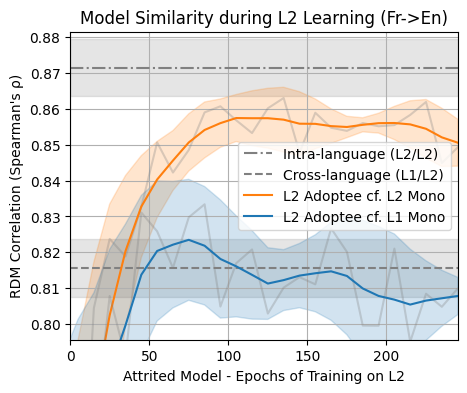

In [180]:
x = np.clip((np.arange(len(fr5en245_cf_en_scores))) * 10 - 5, a_min=0, a_max=None)
plot_sim(x, en_en_score, fr_en_score, fr5en245_cf_en_scores, fr5en245_cf_fr_scores, "Fr->En")

In [143]:

hparams = load_hparams_and_checkpoint("fr5_en245_flatlr_take2")

ckpts = sorted(hparams["checkpointer"].list_checkpoints(), key=ckpt_recency)
fr5en245_take2_cf_fr_scores = []
fr5en245_take2_cf_en_scores = []
for ckpt in ckpts:
    hparams["checkpointer"].load_checkpoint(ckpt)
    reps = generate_reps_from_model(hparams, fr_subset)
    rsm = make_rsm(reps)
    fr5en245_take2_cf_fr_scores.append(compute_spearman_rank(rsm, fr_flat_rsm_fr_data).cpu().detach())
    fr5en245_take2_cf_en_scores.append(compute_spearman_rank(rsm, en_flat_rsm_fr_data).cpu().detach())

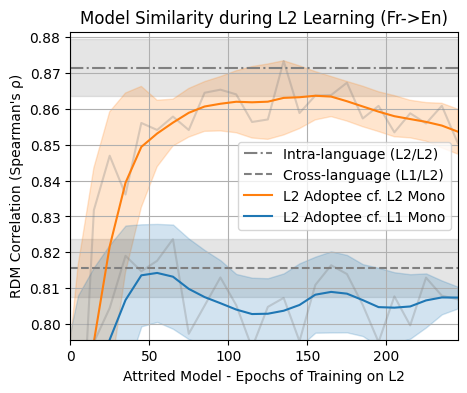

In [181]:
plot_sim(x, en_en_score, fr_en_score, fr5en245_take2_cf_en_scores, fr5en245_take2_cf_fr_scores, "Fr->En")

In [147]:
hparams = load_hparams_and_checkpoint("fr250_flatlr")
fr_flat_reps_en_data = generate_reps_from_model(hparams, en_subset)
fr_flat_rsm_en_data = make_rsm(fr_flat_reps_en_data)

In [148]:
hparams = load_hparams_and_checkpoint("fr250_flatlr_take2")
fr_flat_reps_en_data_take2 = generate_reps_from_model(hparams, en_subset)
fr_flat_rsm_en_data_take2 = make_rsm(fr_flat_reps_en_data_take2)

In [149]:
fr_fr_score_en = compute_spearman_rank(fr_flat_rsm_en_data, fr_flat_rsm_en_data_take2).cpu().detach()
print(f"Similarity of Fr and Fr models on English samples: {fr_fr_score_en:.1%}")

Similarity of Fr and Fr models on English samples: 87.0%


In [150]:
hparams = load_hparams_and_checkpoint("en250_flatlr")
en_flat_reps_en_data = generate_reps_from_model(hparams, en_subset)
en_flat_rsm_en_data = make_rsm(en_flat_reps_en_data)

In [152]:
fr_en_score_en = compute_spearman_rank(fr_flat_rsm_en_data, en_flat_rsm_en_data).cpu().detach()
print(f"Similarity of Fr and En models on English samples: {fr_en_score_en:.1%}")

Similarity of Fr and En models on English samples: 73.3%


In [151]:
hparams = load_hparams_and_checkpoint("en5_fr245_flatlr")

ckpts = sorted(hparams["checkpointer"].list_checkpoints(), key=ckpt_recency)
en5fr245_cf_fr_scores = []
en5fr245_cf_en_scores = []
for ckpt in ckpts:
    hparams["checkpointer"].load_checkpoint(ckpt)
    reps = generate_reps_from_model(hparams, en_subset)
    rsm = make_rsm(reps)
    en5fr245_cf_fr_scores.append(compute_spearman_rank(rsm, fr_flat_rsm_en_data).cpu().detach())
    en5fr245_cf_en_scores.append(compute_spearman_rank(rsm, en_flat_rsm_en_data).cpu().detach())

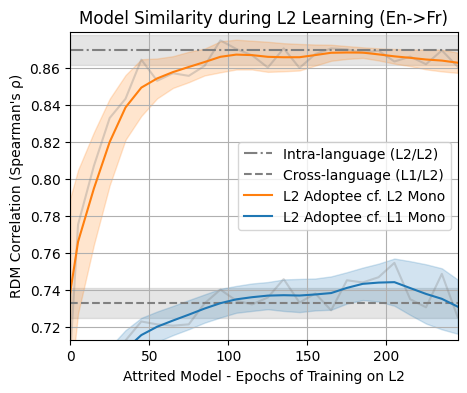

In [182]:
plot_sim(x, fr_fr_score_en, fr_en_score_en, en5fr245_cf_fr_scores, en5fr245_cf_en_scores, "En->Fr")

# Not great TM, what if we transition more slowly?

In [183]:
hparams = load_hparams_and_checkpoint("en6_ramp4_fr240")

ckpts = list(sorted(hparams["checkpointer"].list_checkpoints(), key=ckpt_recency))[-24:]
en6_ramp4_fr240_cf_fr_scores = []
en6_ramp4_fr240_cf_en_scores = []
for ckpt in ckpts:
    hparams["checkpointer"].load_checkpoint(ckpt)
    reps = generate_reps_from_model(hparams, en_subset)
    rsm = make_rsm(reps)
    en6_ramp4_fr240_cf_fr_scores.append(compute_spearman_rank(rsm, fr_flat_rsm_en_data).cpu().detach())
    en6_ramp4_fr240_cf_en_scores.append(compute_spearman_rank(rsm, en_flat_rsm_en_data).cpu().detach())

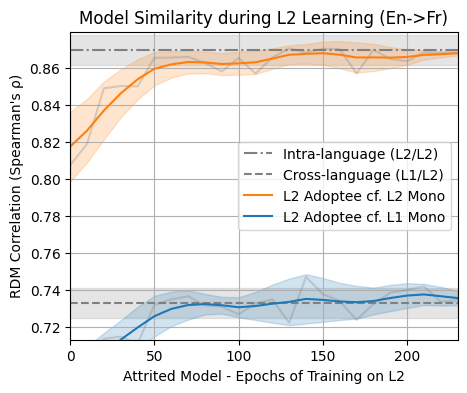

In [185]:
x = np.arange(24) * 10
plot_sim(x, fr_fr_score_en, fr_en_score_en, en6_ramp4_fr240_cf_fr_scores, en6_ramp4_fr240_cf_en_scores, "En->Fr")

In [186]:
hparams = load_hparams_and_checkpoint("en9_ramp1_fr240")

ckpts = list(sorted(hparams["checkpointer"].list_checkpoints(), key=ckpt_recency))[-24:]
en9_ramp1_fr240_cf_fr_scores = []
en9_ramp1_fr240_cf_en_scores = []
for ckpt in ckpts:
    hparams["checkpointer"].load_checkpoint(ckpt)
    reps = generate_reps_from_model(hparams, en_subset)
    rsm = make_rsm(reps)
    en9_ramp1_fr240_cf_fr_scores.append(compute_spearman_rank(rsm, fr_flat_rsm_en_data).cpu().detach())
    en9_ramp1_fr240_cf_en_scores.append(compute_spearman_rank(rsm, en_flat_rsm_en_data).cpu().detach())

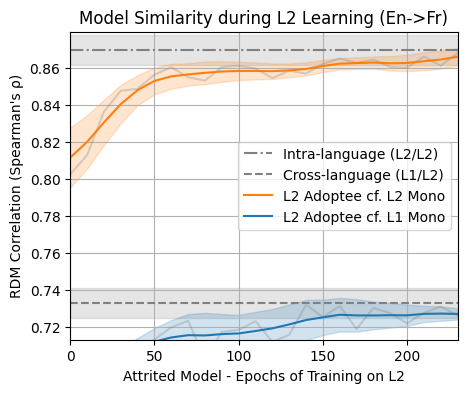

In [187]:
plot_sim(x, fr_fr_score_en, fr_en_score_en, en9_ramp1_fr240_cf_fr_scores, en9_ramp1_fr240_cf_en_scores, "En->Fr")

In [189]:
hparams = load_hparams_and_checkpoint("fr16_ramp4_en140")

ckpts = list(sorted(hparams["checkpointer"].list_checkpoints(), key=ckpt_recency))[-14:]
fr16_ramp4_en140_cf_fr_scores = []
fr16_ramp4_en140_cf_en_scores = []
for ckpt in ckpts:
    hparams["checkpointer"].load_checkpoint(ckpt)
    reps = generate_reps_from_model(hparams, fr_subset)
    rsm = make_rsm(reps)
    fr16_ramp4_en140_cf_fr_scores.append(compute_spearman_rank(rsm, fr_flat_rsm_fr_data).cpu().detach())
    fr16_ramp4_en140_cf_en_scores.append(compute_spearman_rank(rsm, en_flat_rsm_fr_data).cpu().detach())

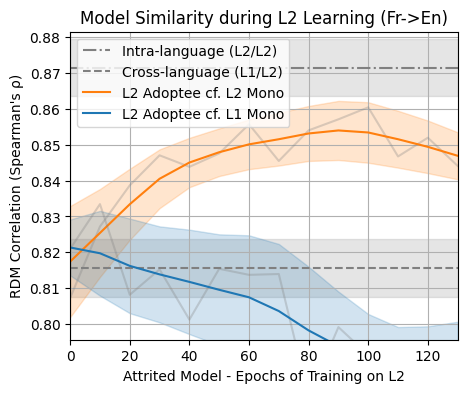

In [191]:
plot_sim(np.arange(14) * 10, en_en_score, fr_en_score, fr16_ramp4_en140_cf_en_scores, fr16_ramp4_en140_cf_fr_scores, "Fr->En")

# Still disappointing. Maybe the warmup is needed, but not cooldown?

In [192]:
hparams = load_hparams_and_checkpoint("fr250_warmup_flatlr")
fr_warm_reps_fr_data = generate_reps_from_model(hparams, fr_subset)
fr_warm_rsm_fr_data = make_rsm(fr_warm_reps_fr_data)

In [193]:
hparams = load_hparams_and_checkpoint("fr250_warmup_flatlr_take2")
fr_warm_reps_fr_data_take2 = generate_reps_from_model(hparams, fr_subset)
fr_warm_rsm_fr_data_take2 = make_rsm(fr_warm_reps_fr_data_take2)

In [199]:
fr_fr_score = compute_spearman_rank(fr_warm_rsm_fr_data, fr_warm_rsm_fr_data_take2).cpu().detach()
print(f"Similarity of Fr and Fr models on French samples: {fr_fr_score:.1%}")

Similarity of Fr and Fr models on French samples: 88.8%


In [195]:
hparams = load_hparams_and_checkpoint("en250_warmup_flatlr_take2")
en_warm_reps_fr_data_take2 = generate_reps_from_model(hparams, fr_subset)
en_warm_rsm_fr_data_take2 = make_rsm(en_warm_reps_fr_data_take2)

In [198]:
fr_en_score = compute_spearman_rank(fr_warm_rsm_fr_data, en_warm_rsm_fr_data_take2).cpu().detach()
print(f"Similarity of Fr and En models on French samples: {fr_en_score:.1%}")

Similarity of Fr and En models on French samples: 79.0%


In [207]:
hparams = load_hparams_and_checkpoint("fr30_en250_warmup_nodecay")

ckpts = list(sorted(hparams["checkpointer"].list_checkpoints(), key=ckpt_recency))
fr30_en250_warm_cf_fr_scores = []
fr30_en250_warm_cf_en_scores = []
for ckpt in ckpts:
    hparams["checkpointer"].load_checkpoint(ckpt)
    reps = generate_reps_from_model(hparams, fr_subset)
    rsm = make_rsm(reps)
    fr30_en250_warm_cf_fr_scores.append(compute_spearman_rank(rsm, fr_warm_rsm_fr_data_take2).cpu().detach())
    fr30_en250_warm_cf_en_scores.append(compute_spearman_rank(rsm, en_warm_rsm_fr_data_take2).cpu().detach())

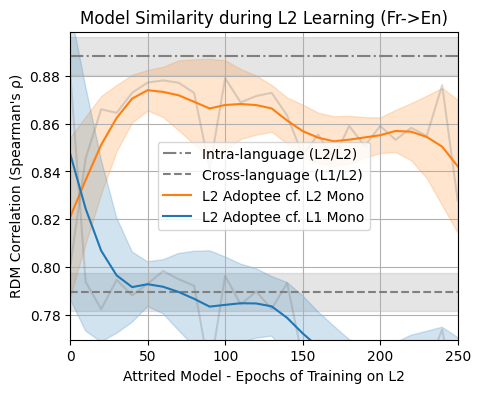

In [208]:
x = np.arange(len(fr30_en250_warm_cf_en_scores)) * 10
plot_sim(x, fr_fr_score, fr_en_score, fr30_en250_warm_cf_en_scores, fr30_en250_warm_cf_fr_scores, "Fr->En")

In [209]:
# Maybe if we go back to a single word?

# But first, try the decay ones to see if our first results were just a fluke...
hparams = load_hparams_and_checkpoint("fr250_decay")
fr_decay_reps_fr_data = generate_reps_from_model(hparams, fr_subset)
fr_decay_rsm_fr_data = make_rsm(fr_decay_reps_fr_data)

In [210]:
# But first, try the decay ones to see if our first results were just a fluke...
hparams = load_hparams_and_checkpoint("en250_decay")
en_decay_reps_fr_data = generate_reps_from_model(hparams, fr_subset)
en_decay_rsm_fr_data = make_rsm(en_decay_reps_fr_data)

In [211]:
fr_en_score = compute_spearman_rank(fr_decay_rsm_fr_data, en_decay_rsm_fr_data).cpu().detach()
print(f"Similarity of Fr and En models on French samples: {fr_en_score:.1%}")

Similarity of Fr and En models on French samples: 76.8%


In [212]:
hparams = load_hparams_and_checkpoint("fr30_en250_warmup_decay")

ckpts = list(sorted(hparams["checkpointer"].list_checkpoints(), key=ckpt_recency))
fr30_en250_decay_cf_fr_scores = []
fr30_en250_decay_cf_en_scores = []
for ckpt in ckpts:
    hparams["checkpointer"].load_checkpoint(ckpt)
    reps = generate_reps_from_model(hparams, fr_subset)
    rsm = make_rsm(reps)
    fr30_en250_decay_cf_fr_scores.append(compute_spearman_rank(rsm, fr_decay_rsm_fr_data).cpu().detach())
    fr30_en250_decay_cf_en_scores.append(compute_spearman_rank(rsm, en_decay_rsm_fr_data).cpu().detach())

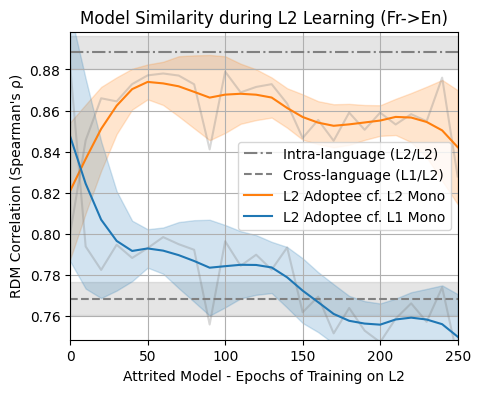

In [213]:
x = np.arange(len(fr30_en250_decay_cf_en_scores)) * 10
plot_sim(x, fr_fr_score, fr_en_score, fr30_en250_warm_cf_en_scores, fr30_en250_warm_cf_fr_scores, "Fr->En")